<a href="https://colab.research.google.com/github/leelavardhan2005/Aadhaar-Data-Analytics-and-AI-Assistant-System/blob/main/%E2%80%9CAadhaar_Enrollment_%26_Biometric_Analysis_System%E2%80%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
enroll = pd.read_csv("/content/api_data_aadhar_enrolment_0_500000.csv")


In [ ]:
demographic = pd.read_csv("/content/api_data_aadhar_demographic_0_500000 - Copy.csv")

In [ ]:
biometric = pd.read_csv("/content/api_data_aadhar_biometric_0_500000.csv")

In [ ]:
#print(enroll.head())
#print(demographic.head())
#print(biometric.head())

In [ ]:
#print(enroll.columns)
#print(demographic.columns)
#print(biometric.columns)

In [ ]:
#Data Cleaning

In [ ]:
# Convert date to proper format
enroll['date'] = pd.to_datetime(enroll['date'], errors='coerce')
demographic['date'] = pd.to_datetime(demographic['date'], errors='coerce')
biometric['date'] = pd.to_datetime(biometric['date'], errors='coerce')

# Remove duplicates
enroll = enroll.drop_duplicates()
demographic = demographic.drop_duplicates()
biometric = biometric.drop_duplicates()

# Check missing values
print(enroll.isnull().sum())
print(demographic.isnull().sum())
print(biometric.isnull().sum())

date              180854
state                  0
district               0
pincode                0
age_0_5                0
age_5_17               0
age_18_greater         0
dtype: int64
date             186273
state                 0
district              0
pincode               0
demo_age_5_17         0
demo_age_17_          0
dtype: int64
date            130715
state                0
district             0
pincode              0
bio_age_5_17         0
bio_age_17_          0
dtype: int64


In [ ]:
# Merge enrollment + demographic
df = pd.merge(enroll, demographic,
              on=['date','state','district','pincode'],
              how='inner')

# Merge with biometric
df = pd.merge(df, biometric,
              on=['date','state','district','pincode'],
              how='inner')

df.head()

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_
0,NaT,Assam,Marigaon,782104,10,11,46,1,32,8,5
1,NaT,Assam,Marigaon,782104,10,11,46,1,32,21,3
2,NaT,Assam,Marigaon,782104,10,11,46,1,32,16,4
3,NaT,Assam,Marigaon,782104,10,11,46,1,32,5,3
4,NaT,Assam,Marigaon,782104,10,11,46,1,32,19,4


In [ ]:
print(df.shape)

In [ ]:
df['total_enrollment'] = df['age_0_5'] + df['age_5_17'] + df['age_18_greater']
df['total_demo'] = df['demo_age_5_17'] + df['demo_age_17_']
df['total_bio'] = df['bio_age_5_17'] + df['bio_age_17_']

In [ ]:
df.groupby('state')['total_enrollment'].sum().sort_values(ascending=False)

,total_enrollment
state,
Uttar Pradesh,11113841
Bihar,8523599
West Bengal,5062312
Madhya Pradesh,5048536
Rajasthan,4267391
Maharashtra,3998051
Jharkhand,2203190
Gujarat,1941439
Tamil Nadu,1874039


In [ ]:
df[['total_enrollment','total_bio']].head()

,total_enrollment,total_bio
0,67,13
1,67,24
2,67,20
3,67,8
4,67,23


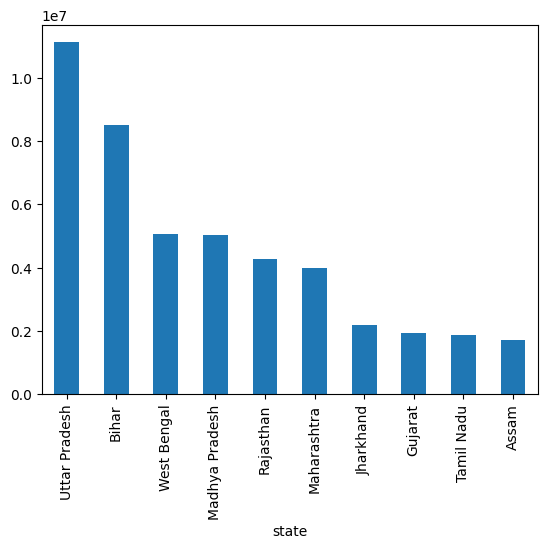

In [ ]:
top_states = df.groupby('state')['total_enrollment'].sum().nlargest(10)
top_states.plot(kind='bar')
plt.show()

In [ ]:
enroll['date'] = pd.to_datetime(enroll['date'], format='%d-%m-%Y', errors='coerce')
demographic['date'] = pd.to_datetime(demographic['date'], format='%d-%m-%Y', errors='coerce')
biometric['date'] = pd.to_datetime(biometric['date'], format='%d-%m-%Y', errors='coerce')

In [ ]:
df['date'].head()

In [ ]:
enroll_grouped = enroll.groupby(['state','district','pincode'], as_index=False).sum(numeric_only=True)
demographic_grouped = demographic.groupby(['state','district','pincode'], as_index=False).sum(numeric_only=True)
biometric_grouped = biometric.groupby(['state','district','pincode'], as_index=False).sum(numeric_only=True)

In [ ]:
df = pd.merge(enroll_grouped, demographic_grouped,
              on=['state','district','pincode'], how='inner')

df = pd.merge(df, biometric_grouped,
              on=['state','district','pincode'], how='inner')

In [ ]:
print(df.shape)
df.head()


In [ ]:
df['total_enrollment'] = df['age_0_5'] + df['age_5_17'] + df['age_18_greater']

df['total_demographic'] = df['demo_age_5_17'] + df['demo_age_17_']

df['total_biometric'] = df['bio_age_5_17'] + df['bio_age_17_']

In [ ]:
#Start Real Analysis (EDA)

In [ ]:
state_enroll = df.groupby('state')['total_enrollment'].sum().sort_values(ascending=False)

state_enroll.head(10)

,total_enrollment
state,
Uttar Pradesh,624478
Bihar,349946
Madhya Pradesh,259789
Maharashtra,198741
Rajasthan,190237
West Bengal,173351
Gujarat,169762
Assam,158004
Meghalaya,98758


In [ ]:
df[['total_enrollment','total_biometric']].describe()

,total_enrollment,total_biometric
count,26705.000000,26705.00000
mean,108.382138,1817.46759
std,372.466963,2839.73225
min,1.000000,1.00000
25%,7.000000,281.00000
50%,22.000000,884.00000
75%,73.000000,2197.00000
max,12584.000000,51763.00000


In [ ]:
df.groupby('district')['total_enrollment'].sum().sort_values(ascending=False).head(10)

,total_enrollment
district,
Sitamarhi,33880
Bahraich,32160
Thane,28087
East Khasi Hills,25636
Sitapur,22511
West Champaran,20651
Agra,20228
Muzaffarpur,19788
Bengaluru,19329


In [ ]:
#Visualization

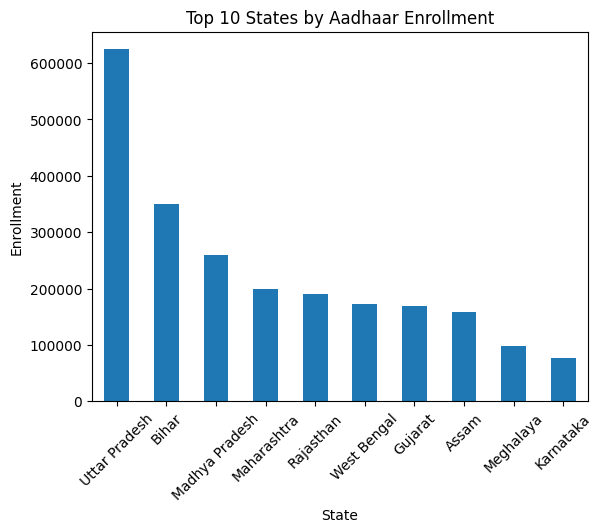

In [ ]:
import matplotlib.pyplot as plt

top_states = state_enroll.head(10)

top_states.plot(kind='bar')
plt.title("Top 10 States by Aadhaar Enrollment")
plt.xlabel("State")
plt.ylabel("Enrollment")
plt.xticks(rotation=45)
plt.show()

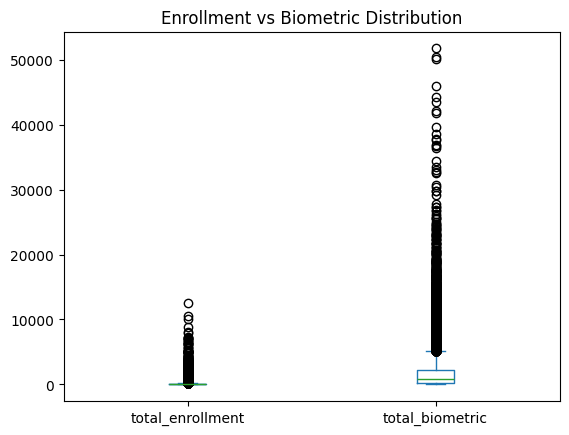

In [ ]:
df[['total_enrollment','total_biometric']].plot(kind='box')
plt.title("Enrollment vs Biometric Distribution")
plt.show()

In [ ]:
Machine Learning Enrolment prediction

In [ ]:
df['total_enrollment'] = df['age_0_5'] + df['age_5_17'] + df['age_18_greater']

df['total_demo'] = df['demo_age_5_17'] + df['demo_age_17_']
df['total_bio'] = df['bio_age_5_17'] + df['bio_age_17_']

# Ratios (VERY IMPORTANT)
df['child_ratio'] = df['age_0_5'] / (df['total_enrollment'] + 1)
df['teen_ratio'] = df['age_5_17'] / (df['total_enrollment'] + 1)
df['adult_ratio'] = df['age_18_greater'] / (df['total_enrollment'] + 1)

df['bio_demo_ratio'] = df['total_bio'] / (df['total_demo'] + 1)

In [ ]:
MODEL 1: Predict Future Enrollment by STATE

In [ ]:
state_df = df.groupby('state').agg({
    'total_enrollment':'sum',
    'total_demo':'sum',
    'total_bio':'sum'
}).reset_index()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_state = LabelEncoder()
state_df['state_encoded'] = le_state.fit_transform(state_df['state'])

In [ ]:
from sklearn.ensemble import RandomForestRegressor

X = state_df[['state_encoded','total_demo','total_bio']]
y = state_df['total_enrollment']

model_state = RandomForestRegressor(n_estimators=100)
model_state.fit(X, y)

RandomForestRegressor()

In [ ]:
state_df['predicted_enrollment'] = model_state.predict(X)

# Top future states
state_df.sort_values('predicted_enrollment', ascending=False).head(10)

,state,total_enrollment,total_demo,total_bio,state_encoded,predicted_enrollment
42,Uttar Pradesh,624478,2200196,6640542,42,488810.25
5,Bihar,349946,1219227,3541825,5,290154.29
26,Maharashtra,198741,1079436,5998536,26,239771.45
25,Madhya Pradesh,259789,873804,4599900,25,236077.50
37,Rajasthan,190237,823793,2842451,37,181080.21
46,West Bengal,173351,973398,1774160,46,175974.53
15,Gujarat,169762,519972,2452172,15,128434.90
4,Assam,158004,239745,573426,4,120634.56
39,Tamil Nadu,77300,536492,3022186,39,98476.60
2,Andhra Pradesh,40661,573737,2550987,2,81557.62


In [ ]:
MODEL 2: Predict Dominant AGE GROUP by STATE

In [ ]:
age_state = df.groupby('state').agg({
    'age_0_5':'sum',
    'age_5_17':'sum',
    'age_18_greater':'sum'
}).reset_index()

In [ ]:
import numpy as np

age_state['dominant_age'] = np.where(
    (age_state['age_0_5'] > age_state['age_5_17']) & (age_state['age_0_5'] > age_state['age_18_greater']), 'Child',
    np.where(
        (age_state['age_5_17'] > age_state['age_18_greater']), 'Teen',
        'Adult'
    )
)

In [ ]:
le_age = LabelEncoder()
age_state['age_label'] = le_age.fit_transform(age_state['dominant_age'])

X = age_state[['age_0_5','age_5_17','age_18_greater']]
y = age_state['age_label']

from sklearn.ensemble import RandomForestClassifier

model_age = RandomForestClassifier()
model_age.fit(X, y)

RandomForestClassifier()

In [ ]:
age_state['predicted_age_group'] = le_age.inverse_transform(model_age.predict(X))

age_state[['state','predicted_age_group']]

,state,predicted_age_group
0,Andaman & Nicobar Islands,Child
1,Andaman and Nicobar Islands,Child
2,Andhra Pradesh,Child
3,Arunachal Pradesh,Teen
4,Assam,Child
5,Bihar,Teen
6,Chandigarh,Child
7,Chhattisgarh,Child
8,Dadra & Nagar Haveli,Child
9,Dadra and Nagar Haveli,Child


In [ ]:
MODEL 3: Predict High Enrollment DISTRICTS (City-level)

In [ ]:
district_df = df.groupby(['state','district']).agg({
    'total_enrollment':'sum',
    'total_demo':'sum',
    'total_bio':'sum'
}).reset_index()

In [ ]:
le_dist = LabelEncoder()
district_df['district_encoded'] = le_dist.fit_transform(district_df['district'])

In [ ]:
X = district_df[['district_encoded','total_demo','total_bio']]
y = district_df['total_enrollment']

model_dist = RandomForestRegressor(n_estimators=100)
model_dist.fit(X, y)

RandomForestRegressor()

In [ ]:
district_df['predicted_enrollment'] = model_dist.predict(X)

district_df.sort_values('predicted_enrollment', ascending=False).head(10)

,state,district,total_enrollment,total_demo,total_bio,district_encoded,predicted_enrollment
153,Bihar,Sitamarhi,33880,44086,131306,770,26184.13
838,Uttar Pradesh,Bahraich,32160,29285,120726,53,23087.04
532,Maharashtra,Thane,28087,114864,355545,821,21892.92
907,Uttar Pradesh,Sitapur,22511,44514,194992,771,17821.39
365,Karnataka,Bengaluru,19329,83803,216234,97,17714.40
123,Bihar,East Champaran,18210,67431,152426,232,17318.77
157,Bihar,West Champaran,20651,59109,117410,889,17293.60
220,Delhi,West Delhi,15192,101427,139531,890,16860.69
956,West Bengal,Murshidabad,17840,99523,154006,553,16744.58
255,Gujarat,Surat,16301,129660,207106,809,16735.61


In [ ]:
df.to_csv("final_aadhar_data.csv", index=False)

In [ ]:
#Create final prediction table

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# =========================
# 1. STATE PREDICTION
# =========================
state_df = df.groupby('state').agg({
    'total_enrollment':'sum',
    'total_demo':'sum',
    'total_bio':'sum'
}).reset_index()

le_state = LabelEncoder()
state_df['state_encoded'] = le_state.fit_transform(state_df['state'])

X_state = state_df[['state_encoded','total_demo','total_bio']]
y_state = state_df['total_enrollment']

model_state = RandomForestRegressor(n_estimators=100)
model_state.fit(X_state, y_state)

state_df['predicted_enrollment'] = model_state.predict(X_state)

# =========================
# 2. AGE PREDICTION
# =========================
age_df = df.groupby('state').agg({
    'age_0_5':'sum',
    'age_5_17':'sum',
    'age_18_greater':'sum'
}).reset_index()

age_df['dominant_age'] = np.where(
    (age_df['age_0_5'] > age_df['age_5_17']) & (age_df['age_0_5'] > age_df['age_18_greater']), 'Child',
    np.where(
        (age_df['age_5_17'] > age_df['age_18_greater']), 'Teen',
        'Adult'
    )
)

le_age = LabelEncoder()
age_df['age_label'] = le_age.fit_transform(age_df['dominant_age'])

X_age = age_df[['age_0_5','age_5_17','age_18_greater']]
y_age = age_df['age_label']

model_age = RandomForestClassifier(n_estimators=100)
model_age.fit(X_age, y_age)

age_df['predicted_age_group'] = le_age.inverse_transform(model_age.predict(X_age))

# =========================
# 3. DISTRICT PREDICTION
# =========================
district_df = df.groupby(['state','district']).agg({
    'total_enrollment':'sum',
    'total_demo':'sum',
    'total_bio':'sum'
}).reset_index()

le_dist = LabelEncoder()
district_df['district_encoded'] = le_dist.fit_transform(district_df['district'])

X_dist = district_df[['district_encoded','total_demo','total_bio']]
y_dist = district_df['total_enrollment']

model_dist = RandomForestRegressor(n_estimators=100)
model_dist.fit(X_dist, y_dist)

district_df['predicted_district_enrollment'] = model_dist.predict(X_dist)

# =========================
# 4. MERGE EVERYTHING
# =========================

# Merge state + age
final_pred = pd.merge(state_df, age_df[['state','predicted_age_group']], on='state')

# Merge district predictions
final_pred = pd.merge(final_pred, district_df[['state','district','predicted_district_enrollment']], on='state')

# =========================
# 5. SAVE FINAL DATASET
# =========================
final_pred.to_csv("final_ml_predictions.csv", index=False)

print("Final dataset created successfully!")

Final dataset created successfully!


In [ ]:
#RAG

In [ ]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import pandas as pd

df = pd.read_csv("/content/final_aadhar_data.csv").sample(2000)

# Convert to text
df['text'] = df.apply(
    lambda row: f"State {row['state']} district {row['district']} has enrollment {row['total_enrollment']} and demographic {row['total_demo']} and biometric {row['total_bio']}",
    axis=1
)

# Create embeddings
model_embed = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model_embed.encode(df['text'].tolist())

# Store in FAISS
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def search(query):
    query_embedding = model_embed.encode([query])
    distances, indices = index.search(query_embedding, k=5)
    return df.iloc[indices[0]]

In [ ]:
def get_context(query):
    results = search(query)
    context = "\n".join(results['text'].tolist())
    return context

In [ ]:
from transformers import pipeline

llm = pipeline("text-generation", model="distilgpt2")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def ask_bot(query):
    context = get_context(query)

    prompt = f"""
    Data:
    {context}

    Question: {query}
    Answer:
    """

    response = llm(prompt, max_length=150)
    return response[0]['generated_text']

In [ ]:
while True:
    user_query = input("Ask your question: ")

    if user_query.lower() == "exit":
        break

    print("\nAI Answer:\n", ask_bot(user_query))

Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



AI Answer:
 
    Data:
    State Himachal Pradesh district Una has enrollment 3 and demographic 59 and biometric 444
State Himachal Pradesh district Kullu has enrollment 3 and demographic 26 and biometric 251
State Himachal Pradesh district Una has enrollment 7 and demographic 7 and biometric 325
State Mizoram district Hnahthial has enrollment 1 and demographic 13 and biometric 2
State Himachal Pradesh district Una has enrollment 2 and demographic 16 and biometric 193

    Question: “Which state has highest enrollment?”
    Answer:
      State Himachal Pradesh district Una has enrollment 1 and demographic 15 and biometric 228
State Himachal Pradesh district Una has enrollment 2 and demographic 11 and biometric 240
State Himachal Pradesh district Una has enrollment 1 and demographic 10 and biometric 234
State Himachal Pradesh district Una has enrollment 0 and demographic 20 and biometric 254
State Himachal Pradesh district Una has enrollment 0 and demographic 9 and biometric 234
State 


KeyboardInterrupt

